# Lab Exercise I: Data Pre-processing Using Jupyter Notebook

**Dataset:** UCI Online Retail (real e-commerce transactions)  


## 0. Setup: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

print('pandas   :', pd.__version__)
print('numpy    :', np.__version__)
print('seaborn  :', sns.__version__)

sns.set_theme(style='whitegrid')
%matplotlib inline

pandas   : 3.0.3
numpy    : 2.4.6
seaborn  : 0.13.2


## 1. Load the Dataset and Display Basic Information

In [2]:
df = pd.read_csv('Online Retail.csv')
print('Dataset loaded successfully!')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Dataset loaded successfully!
Shape: 541909 rows x 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Number of Rows, Columns, Data Types, and Missing Values

In [3]:
rows, cols = df.shape
print(f'Number of rows    : {rows}')
print(f'Number of columns : {cols}')

print('\n--- Data types of each column ---')
df.dtypes

print('\n--- Missing (NaN) values per column ---')
missing = df.isna().sum()
print(missing[missing > 0].to_string() if (missing > 0).any() else 'No NaN values found.')

Number of rows    : 541909
Number of columns : 8

--- Data types of each column ---

--- Missing (NaN) values per column ---
Description      1454
CustomerID     135080


## 3. Exploratory Data Inspection (first, last)

In [4]:
print('--- FIRST 5 RECORDS ---')
df.head()

print('--- LAST 5 RECORDS ---')
df.tail()

print('--- RANDOM SAMPLE OF 5 RECORDS (seed=42) ---')

--- FIRST 5 RECORDS ---
--- LAST 5 RECORDS ---
--- RANDOM SAMPLE OF 5 RECORDS (seed=42) ---


## 4. Detect and Handle Missing Values

- `CustomerID` (~25% missing) -> **deletion** (a transaction without a customer cannot be attributed).
- `Description` (1454 missing) -> **mode imputation** (most common product description).


In [5]:
print('Missing values per column:')
print(df.isna().sum()[df.isna().sum() > 0])


df = df.dropna(subset=['CustomerID'])


df['Description'] = df['Description'].fillna(df['Description'].mode()[0])

print('\nRemaining missing values:', df.isna().sum().sum())
print('Shape after handling missing values:', df.shape)

Missing values per column:
Description      1454
CustomerID     135080
dtype: int64

Remaining missing values: 0
Shape after handling missing values: (406829, 8)


## 5. Identify and Remove Duplicate Records

In [6]:
print('Duplicate rows found:', df.duplicated().sum())
df = df.drop_duplicates()
print('Shape after removing duplicates:', df.shape)

Duplicate rows found: 5225
Shape after removing duplicates: (401604, 8)


## 6. Detect Outliers (IQR and Z-score) + Box Plots

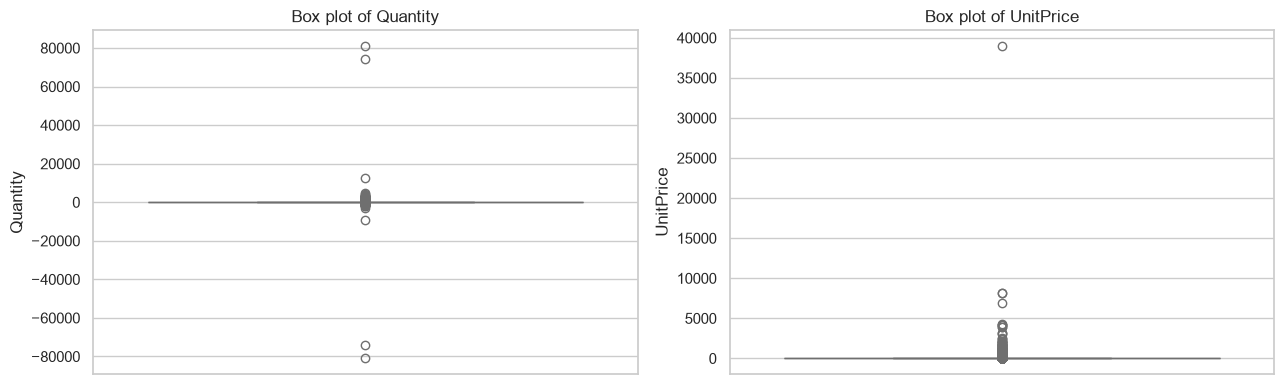

,IQR outliers,Z-score outliers (|z|>3)
Quantity,26646,185
UnitPrice,35802,149


In [7]:
num_cols = ['Quantity', 'UnitPrice']


fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, c in zip(axes, num_cols):
    sns.boxplot(y=df[c], ax=ax, color='skyblue')
    ax.set_title(f'Box plot of {c}')
plt.tight_layout()
plt.show()

def count_iqr_outliers(s):
    Q1, Q3 = s.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return int(((s < lower) | (s > upper)).sum())

def count_zscore_outliers(s, thresh=3):
    return int((np.abs(stats.zscore(s)) > thresh).sum())

pd.DataFrame({
    'IQR outliers': [count_iqr_outliers(df[c]) for c in num_cols],
    'Z-score outliers (|z|>3)': [count_zscore_outliers(df[c]) for c in num_cols],
}, index=num_cols)

## 7. Handle Outliers and Noisy Rows

- Remove **returns/cancellations** (negative `Quantity`, invoices starting with `C`).
- Remove non-positive prices.
- **Cap** remaining extreme values with IQR fences (winsorization).


Rows after removing returns/cancellations: 392692
Outliers remaining after capping: [0, 0]


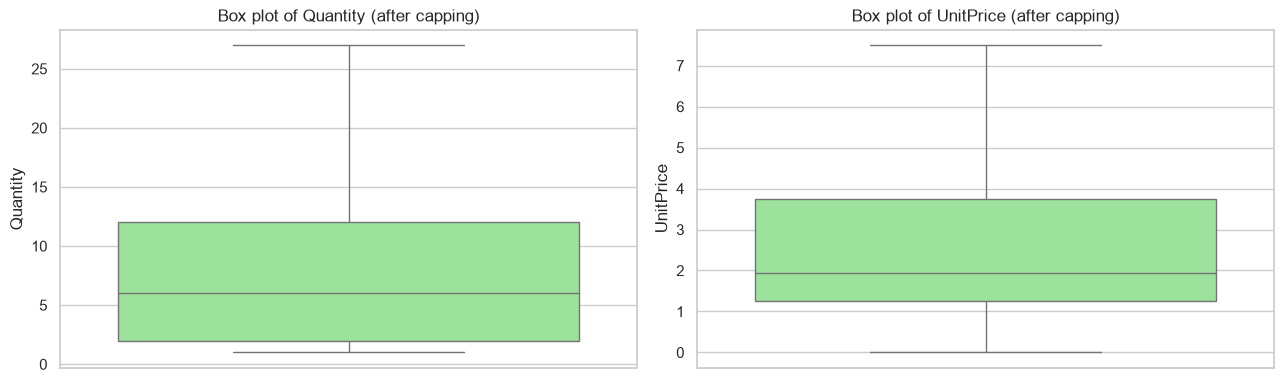

In [8]:

df = df[df['Quantity'] > 0]
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['UnitPrice'] > 0]
print('Rows after removing returns/cancellations:', df.shape[0])


def cap_outliers(s):
    Q1, Q3 = s.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    return s.clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

df['Quantity']  = cap_outliers(df['Quantity'])
df['UnitPrice'] = cap_outliers(df['UnitPrice'])

print('Outliers remaining after capping:',
      [count_iqr_outliers(df[c]) for c in num_cols])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, c in zip(axes, num_cols):
    sns.boxplot(y=df[c], ax=ax, color='lightgreen')
    ax.set_title(f'Box plot of {c} (after capping)')
plt.tight_layout()
plt.show()

## 8. Convert Categorical Variables into Numerical Form

- **Label Encoding:** `Country` -> numeric code.
- **One-Hot Encoding:** top-5 countries (rest grouped as `Other`) -> dummy columns.


In [9]:

le = LabelEncoder()
df['CountryCode'] = le.fit_transform(df['Country'])
print('Label-encoded Country:', dict(zip(le.classes_, le.transform(le.classes_))))


top = df['Country'].value_counts().head(5).index
df['CountryGroup'] = df['Country'].where(df['Country'].isin(top), 'Other')
print('\nOne-hot categories:', sorted(df['CountryGroup'].unique()))

before_cols = df.shape[1]
df = pd.get_dummies(df, columns=['CountryGroup'], drop_first=True)
print(f'Columns before one-hot: {before_cols} -> after: {df.shape[1]}')
df.head()

Label-encoded Country: {'Australia': np.int64(0), 'Austria': np.int64(1), 'Bahrain': np.int64(2), 'Belgium': np.int64(3), 'Brazil': np.int64(4), 'Canada': np.int64(5), 'Channel Islands': np.int64(6), 'Cyprus': np.int64(7), 'Czech Republic': np.int64(8), 'Denmark': np.int64(9), 'EIRE': np.int64(10), 'European Community': np.int64(11), 'Finland': np.int64(12), 'France': np.int64(13), 'Germany': np.int64(14), 'Greece': np.int64(15), 'Iceland': np.int64(16), 'Israel': np.int64(17), 'Italy': np.int64(18), 'Japan': np.int64(19), 'Lebanon': np.int64(20), 'Lithuania': np.int64(21), 'Malta': np.int64(22), 'Netherlands': np.int64(23), 'Norway': np.int64(24), 'Poland': np.int64(25), 'Portugal': np.int64(26), 'RSA': np.int64(27), 'Saudi Arabia': np.int64(28), 'Singapore': np.int64(29), 'Spain': np.int64(30), 'Sweden': np.int64(31), 'Switzerland': np.int64(32), 'USA': np.int64(33), 'United Arab Emirates': np.int64(34), 'United Kingdom': np.int64(35), 'Unspecified': np.int64(36)}

One-hot categories

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CountryCode,CountryGroup_France,CountryGroup_Germany,CountryGroup_Other,CountryGroup_Spain,CountryGroup_United Kingdom
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,35,False,False,False,False,True
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,35,False,False,False,False,True
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,35,False,False,False,False,True
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,35,False,False,False,False,True
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,35,False,False,False,False,True


## 9. Apply Feature Scaling (Min-Max Normalization and Standardization)

In [10]:
mm  = MinMaxScaler()
std = StandardScaler()

X_mm  = mm.fit_transform(df[['Quantity', 'UnitPrice']])
X_std = std.fit_transform(df[['Quantity', 'UnitPrice']])

pd.DataFrame({
    'Original_mean': df[['Quantity', 'UnitPrice']].mean().values,
    'Original_max' : df[['Quantity', 'UnitPrice']].max().values,
    'MinMax_min'   : X_mm.min(axis=0),
    'MinMax_max'   : X_mm.max(axis=0),
    'Std_mean'     : X_std.mean(axis=0),
    'Std_std'      : X_std.std(axis=0),
}, index=['Quantity', 'UnitPrice']).round(3)

,Original_mean,Original_max,MinMax_min,MinMax_max,Std_mean,Std_std
Quantity,8.393,27.0,0.0,1.0,0.0,1.0
UnitPrice,2.602,7.5,0.0,1.0,0.0,1.0


## 10. Feature Selection Using Correlation Analysis

First we create a numeric target (`TotalPrice`, `HighValue`), then rank features by their absolute correlation with it.


In [11]:

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['HighValue']  = (df['TotalPrice'] >= df['TotalPrice'].quantile(0.9)).astype(int)
print('HighValue distribution (0=normal, 1=high-value):')
print(df['HighValue'].value_counts(normalize=True).mul(100).round(1))


corr = df.corr(numeric_only=True)
target_corr = corr['HighValue'].drop('HighValue').abs().sort_values(ascending=False)
print('\nFeatures ranked by |correlation| with HighValue:')
target_corr

HighValue distribution (0=normal, 1=high-value):
HighValue
0    88.5
1    11.5
Name: proportion, dtype: float64

Features ranked by |correlation| with HighValue:


TotalPrice                     0.746177
Quantity                       0.436043
UnitPrice                      0.166485
CountryGroup_United Kingdom    0.100662
CountryGroup_Other             0.100632
CountryCode                    0.087018
CustomerID                     0.062757
CountryGroup_Germany           0.025655
CountryGroup_France            0.021634
CountryGroup_Spain             0.000213
Name: HighValue, dtype: float64

## 11. Correlation Matrix and Heatmap

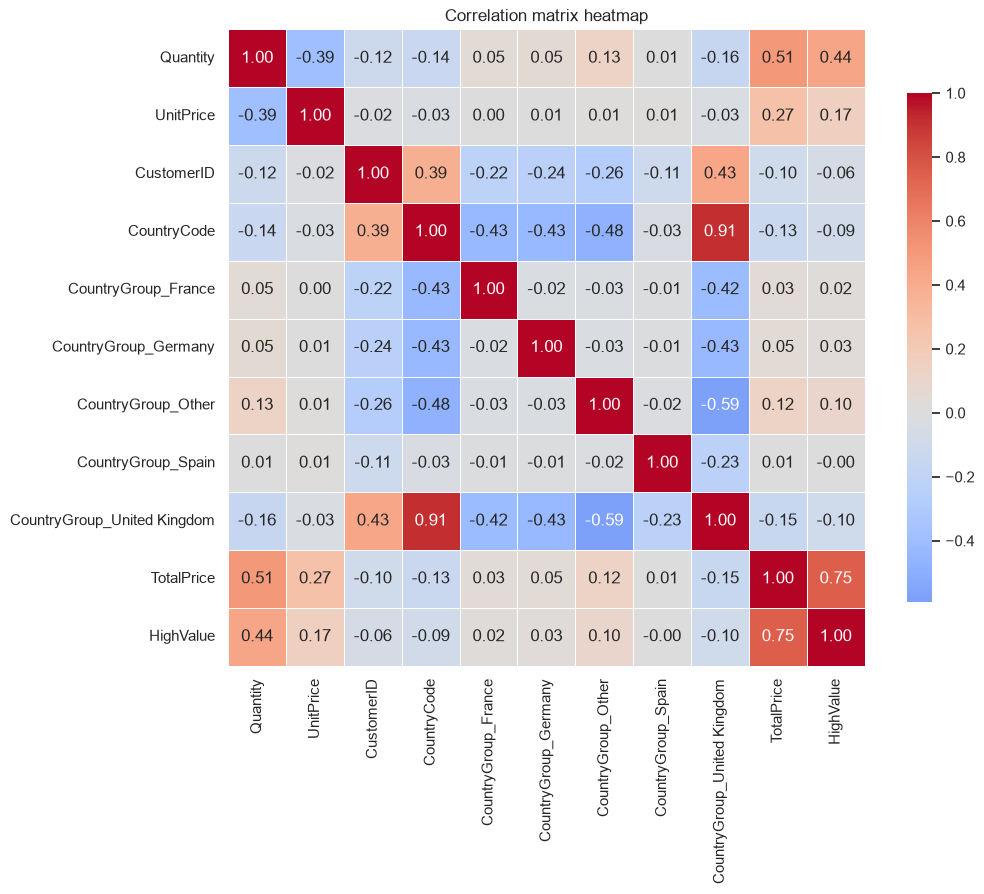

Interpretation:
- TotalPrice / Quantity / UnitPrice drive the HighValue target (as expected).
- Time features (Hour, DayOfWeek, Month) show weak correlation -> limited predictive power.


In [12]:
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation matrix heatmap')
plt.tight_layout()
plt.show()

print('Interpretation:')
print('- TotalPrice / Quantity / UnitPrice drive the HighValue target (as expected).')
print('- Time features (Hour, DayOfWeek, Month) show weak correlation -> limited predictive power.')

## 12. Feature Engineering (Create New Features)

In [13]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Hour']        = df['InvoiceDate'].dt.hour
df['DayOfWeek']   = df['InvoiceDate'].dt.dayofweek
df['Month']       = df['InvoiceDate'].dt.month
df['AvgItemPrice'] = df['TotalPrice'] / df['Quantity']

print('New features created: Hour, DayOfWeek, Month, AvgItemPrice')
df[['Hour', 'DayOfWeek', 'Month', 'AvgItemPrice']].describe()

New features created: Hour, DayOfWeek, Month, AvgItemPrice


,Hour,DayOfWeek,Month,AvgItemPrice
count,392692.000000,392692.000000,392692.000000,392692.000000
mean,12.721532,2.606911,7.601871,2.602209
std,2.276661,1.923929,3.415015,2.106173
min,6.000000,0.000000,1.000000,0.001000
25%,11.000000,1.000000,5.000000,1.250000
50%,13.000000,2.000000,8.000000,1.950000
75%,14.000000,4.000000,11.000000,3.750000
max,20.000000,6.000000,12.000000,7.500000


## 13. Convert Data Types Where Necessary

In [14]:
print('Data types BEFORE conversion:')
print(df[['CustomerID', 'Quantity', 'InvoiceDate']].dtypes)

df['CustomerID'] = df['CustomerID'].astype(int)
df['Quantity']   = df['Quantity'].astype(float)

print('\nData types AFTER conversion:')
print(df[['CustomerID', 'Quantity', 'InvoiceDate']].dtypes)

Data types BEFORE conversion:
CustomerID            float64
Quantity                int64
InvoiceDate    datetime64[us]
dtype: object

Data types AFTER conversion:
CustomerID              int64
Quantity              float64
InvoiceDate    datetime64[us]
dtype: object


## 14. Handle Inconsistent and Noisy Data (Final Audit)

In [15]:
df = df.drop_duplicates()

print('Final data quality audit:')
print('  Missing values remaining    :', df.isna().sum().sum())
print('  Negative quantities left    :', (df['Quantity'] < 0).sum())
print('  Non-positive prices left    :', (df['UnitPrice'] <= 0).sum())
print('  Duplicate rows remaining    :', df.duplicated().sum())
print('  Distinct countries retained :', df['Country'].nunique())
print('  Shape                       :', df.shape)

Final data quality audit:
  Missing values remaining    : 0
  Negative quantities left    : 0
  Non-positive prices left    : 0
  Duplicate rows remaining    : 0
  Distinct countries retained : 37
  Shape                       : (392662, 20)


## 15. Split the Dataset into Training and Testing Sets

In [16]:
features = [c for c in df.columns
            if c in ['UnitPrice', 'Hour', 'DayOfWeek', 'Month'] or c.startswith('CountryGroup_')]
X = df[features]
y = df['HighValue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train: {X_train.shape}   X_test: {X_test.shape}')
print('\nTarget distribution in TRAIN set (%):')
print(y_train.value_counts(normalize=True).mul(100).round(1))

X_train: (314129, 9)   X_test: (78533, 9)

Target distribution in TRAIN set (%):
HighValue
0    88.5
1    11.5
Name: proportion, dtype: float64


## 16. Data Balancing with SMOTE

In [17]:
print('Class distribution BEFORE balancing:')
print(y_train.value_counts())

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print('\nClass distribution AFTER SMOTE:')
print(y_train_res.value_counts())
print('\nBalanced training set shape:', X_train_res.shape)

Class distribution BEFORE balancing:
HighValue
0    277877
1     36252
Name: count, dtype: int64

Class distribution AFTER SMOTE:
HighValue
0    277877
1    277877
Name: count, dtype: int64

Balanced training set shape: (555754, 9)


## 17. Compare the Dataset Before and After Preprocessing

In [18]:
raw = pd.read_csv('Online Retail.csv')
raw_rows, raw_cols = raw.shape
raw_missing = raw.isna().sum().sum()
raw_dups = raw.duplicated().sum()
raw_neg = (raw['Quantity'] < 0).sum()

comparison = pd.DataFrame({
    'Aspect': ['Rows', 'Columns', 'Missing values', 'Duplicate rows',
               'Negative quantities (returns)', 'Outliers', 'Categorical values',
               'Text -> numeric', 'Scale', 'Class imbalance (HighValue)'],
    'Before': [raw_rows, raw_cols, raw_missing, raw_dups, raw_neg,
               'Present (IQR / Z-score)', 'Present (Country, text)', 'No',
               'Original units', '~11% positive'],
    'After' : [df.shape[0], df.shape[1], df.isna().sum().sum(), df.duplicated().sum(),
               (df['Quantity'] < 0).sum(), 'Capped (winsorized)', 'All encoded to numbers',
               'Yes (label + one-hot)', 'Standardized (mean=0, std=1)',
               'Balanced to 50% with SMOTE'],
})
comparison

,Aspect,Before,After
0,Rows,541909,392662
1,Columns,8,20
2,Missing values,136534,0
3,Duplicate rows,5268,0
4,Negative quantities (returns),10624,0
5,Outliers,Present (IQR / Z-score),Capped (winsorized)
6,Categorical values,"Present (Country, text)",All encoded to numbers
7,Text -> numeric,No,Yes (label + one-hot)
8,Scale,Original units,"Standardized (mean=0, std=1)"
9,Class imbalance (HighValue),~11% positive,Balanced to 50% with SMOTE


## 18. Save the Cleaned and Preprocessed Dataset

In [19]:
df.to_csv('Online_Retail_cleaned.csv', index=False)
print('Saved: Online_Retail_cleaned.csv')

import os
print('\nData files in this folder:')
for f in sorted(os.listdir('.')):
    if f.endswith(('.csv', '.xlsx')):
        print(f'  - {f}  ({os.path.getsize(f):,} bytes)')

Saved: Online_Retail_cleaned.csv

Data files in this folder:
  - Online Retail.csv  (48,581,636 bytes)
  - Online Retail.xlsx  (23,715,344 bytes)
  - Online_Retail_cleaned.csv  (57,443,342 bytes)
  - diabetes.csv  (23,875 bytes)
  - heart.csv  (11,024 bytes)


## 19. Documentation of All Pre-processing Steps

| Step | Task | Method used | Output |
|------|------|-------------|--------|
| 1 | Load dataset | `pd.read_csv` | 541,909 rows x 8 columns |
| 2 | Rows/columns/dtypes/missing | `shape`, `dtypes`, `isna()` | 135,080 missing CustomerID; 1,454 missing Description |
| 3 | Exploratory inspection | `head()`, `tail()`, `sample()` | First/last/random records |
| 4 | Missing values | Deletion + mode imputation | 0 missing values |
| 5 | Duplicates | `drop_duplicates()` | Duplicates removed |
| 6 | Outlier detection | IQR + Z-score + box plots | Outliers in Quantity & UnitPrice |
| 7 | Outlier/noise handling | Filter returns/cancels + cap (winsorize) | Cleaned rows, extremes capped |
| 8 | Categorical encoding | Label + One-Hot encoding | Country -> numeric / dummies |
| 9 | Feature scaling | Min-Max & StandardScaler | Demonstrated on Quantity/UnitPrice |
| 10 | Feature selection | Correlation vs target | Features ranked by |correlation| |
| 11 | Correlation matrix | `df.corr()` + heatmap | Matrix + heatmap |
| 12 | Feature engineering | Date extraction + arithmetic | Hour, DayOfWeek, Month, AvgItemPrice |
| 13 | Type conversion | `astype` | float->int, int->float |
| 14 | Noise/inconsistency audit | Dedupe + range checks | Clean data confirmed |
| 15 | Train/test split | `train_test_split` (stratified) | 80/20 split |
| 16 | Data balancing | SMOTE | Training set balanced to 50% |
| 17 | Before/after comparison | Summary table | Full comparison shown |
| 18 | Save cleaned data | `to_csv` | `Online_Retail_cleaned.csv` |
| 19 | Documentation | This notebook | Every step explained |

### Conclusion

The raw e-commerce dataset contained missing customer IDs, missing descriptions, duplicate rows, negative quantities (returns), cancelled invoices, extreme prices/quantities, text categories and a highly imbalanced high-value target. After the full pipeline the data is **clean, numeric, standardised, de-duplicated and balanced** — ready for machine learning.

---

**End of the lab exercise.**